TimesFM is a pretrained foundation model for time-series forecasting. The key idea is zero-shot forecasting: you can give it a historical sequence (context), and it produces future values without training a custom model for your dataset. Google Research introduced it as a decoder-only Transformer specialized for time series, and reported that despite being much smaller than large language models—it can achieve near state of the art accuracy on multiple unseen forecasting benchmarks.

TimesFM aims to reduce that friction:

One general model that works across domains and granularities,

Zero-shot performance that can be competitive with supervised models trained per dataset,

Option to operationalize it as a reusable forecasting component in data platforms (e.g., BigQuery).

Core capabilities

1) Zero-shot forecasting:- TimesFM is designed to forecast accurately on previously unseen datasets without retraining.

2) Works across different horizons and granularities: The paper/blog emphasize flexibility across history length, forecast horizon, and time granularity at inference time.

3) Univariate forecasting focus:- TimesFM’s common public interface is univariate: you provide one target series (optionally with a frequency indicator), and it predicts future points.

**Model architecture (high level)**

Decoder-only Transformer (time-series specific):- TimesFM is built as a decoder-only Transformer (similar in shape to GPT-style decoders, but trained for numeric sequences).

“Patched” / segment-based processing:- Instead of predicting one point at a time naïvely, TimesFM is described as outputting batches of contiguous time-point segments and using a “patched-decoder style attention” design.

Why patching helps: time series can be long; patching/segmenting can reduce effective sequence length and help the model capture multi-scale patterns (trend/seasonality/local fluctuations) more efficiently than raw point-by-point attention.

Training data and scale:- pretraining on roughly O(100B) time points with a ~200M parameter model.

References:-

1.https://arxiv.org/abs/2310.10688

2.https://github.com/google-research/timesfm

3.https://huggingface.co/google/timesfm-1.0-200m


Datasets:- Google Trends

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
All imports successful


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


Google Trends data loaded
2026-01-11    61
2026-01-18    59
2026-01-25    50
2026-02-01    48
2026-02-08    54
Freq: W-SUN, Name: value, dtype: int64


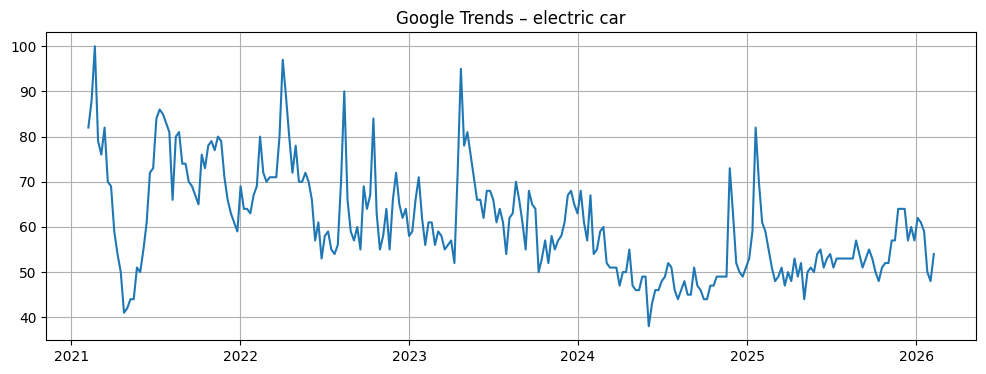

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to 

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

Downloaded.


model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM loaded
             forecast        q10        q50        q90
2026-02-15  53.581562  48.102577  53.581562  61.205128
2026-02-22  53.708027  47.523445  53.708027  62.418816
2026-03-01  53.872883  47.272488  53.872883  63.406399
2026-03-08  53.650318  46.809380  53.650318  63.739662
2026-03-15  53.716621  46.507557  53.716621  64.167267


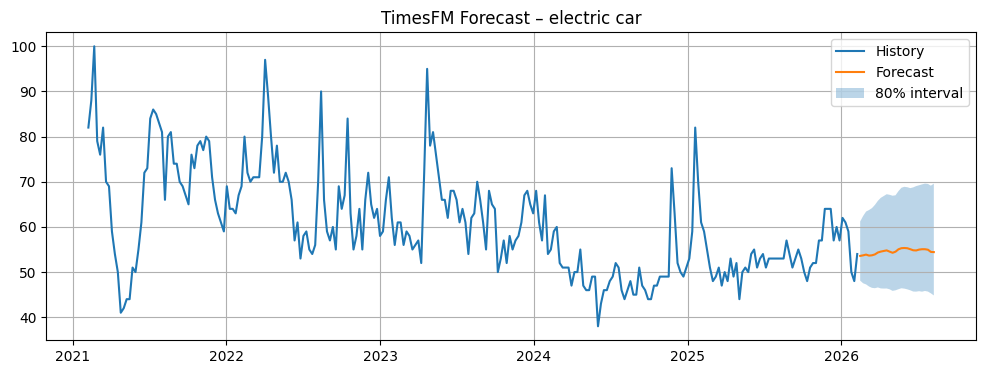

In [1]:
# ================================
# 0. INSTALL DEPENDENCIES (SAFE)
# ================================
!pip -q install pytrends torch transformers safetensors accelerate
!pip -q install git+https://github.com/google-research/timesfm.git

# ================================
# 1. IMPORTS
# ================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pytrends.request import TrendReq

import torch
import timesfm

print("All imports successful")

# ================================
# 2. FETCH GOOGLE TRENDS DATA
# ================================
def fetch_google_trends(keyword, geo="", timeframe="today 5-y"):
    pytrends = TrendReq(hl="en-US", tz=0)
    pytrends.build_payload([keyword], geo=geo, timeframe=timeframe)
    df = pytrends.interest_over_time()

    if df.empty:
        raise ValueError("No data returned from Google Trends")

    if "isPartial" in df.columns:
        df = df.drop(columns=["isPartial"])

    df = df.rename(columns={keyword: "value"})
    df.index = pd.to_datetime(df.index)
    return df

# ================================
# 3. MAKE CONTIGUOUS TIME SERIES
# ================================
def make_contiguous_series(df, freq=None):
    s = df["value"].copy()

    if freq is None:
        freq = pd.infer_freq(s.index) or "W"

    full_index = pd.date_range(
        start=s.index.min(),
        end=s.index.max(),
        freq=freq
    )

    s = s.reindex(full_index)
    s = s.interpolate(limit_direction="both")

    return s

# ================================
# 4. LOAD DATA
# ================================
KEYWORD = "electric car"
GEO = "IN"
TIMEFRAME = "today 5-y"

raw_df = fetch_google_trends(KEYWORD, GEO, TIMEFRAME)
series = make_contiguous_series(raw_df)

print("Google Trends data loaded")
print(series.tail())

# ================================
# 5. PLOT HISTORY
# ================================
plt.figure(figsize=(12,4))
plt.plot(series.index, series.values)
plt.title(f"Google Trends – {KEYWORD}")
plt.grid(True)
plt.show()

# ================================
# 6. LOAD TIMESFM (TORCH CHECKPOINT)
# ================================
torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

config = timesfm.ForecastConfig(
    max_context=1024,
    max_horizon=52,
    normalize_inputs=True,
    use_continuous_quantile_head=True,
    fix_quantile_crossing=True,
)

model.compile(config)

print("TimesFM loaded")

# ================================
# 7. FORECAST
# ================================
HORIZON = 26

point_forecast, quantile_forecast = model.forecast(
    horizon=HORIZON,
    inputs=[series.values.astype(np.float32)],
)

point_forecast = point_forecast[0]
quantile_forecast = quantile_forecast[0]

# ================================
# 8. BUILD FORECAST DATAFRAME
# ================================
freq = pd.infer_freq(series.index) or "W"
future_index = pd.date_range(
    start=series.index[-1],
    periods=HORIZON + 1,
    freq=freq
)[1:]

forecast_df = pd.DataFrame(
    {
        "forecast": point_forecast,
        "q10": quantile_forecast[:, 1],
        "q50": quantile_forecast[:, 5],
        "q90": quantile_forecast[:, 9],
    },
    index=future_index
)

print(forecast_df.head())

# ================================
# 9. PLOT FORECAST
# ================================
plt.figure(figsize=(12,4))
plt.plot(series.index, series.values, label="History")
plt.plot(forecast_df.index, forecast_df["forecast"], label="Forecast")
plt.fill_between(
    forecast_df.index,
    forecast_df["q10"],
    forecast_df["q90"],
    alpha=0.3,
    label="80% interval"
)
plt.legend()
plt.grid(True)
plt.title(f"TimesFM Forecast – {KEYWORD}")
plt.show()

# ================================
# 10. SAVE OUTPUT
# ================================
# forecast_df.to_csv("timesfm_google_trends_forecast.csv")
# print("Saved: timesfm_google_trends_forecast.csv")

What ForecastConfig is controlling, In the script:

max_context: how much history the model is allowed to use (cap for speed/memory)

max_horizon: maximum forecast horizon the compiled graph expects

normalize_inputs=True: the model normalizes inputs internally (often helps across series scales)

use_continuous_quantile_head=True: requests quantile outputs (if available)

fix_quantile_crossing=True: enforces monotonic quantiles (q10 ≤ q20 ≤ … ≤ q90)

In [2]:
from transformers import AutoConfig

MODEL_ID = "google/timesfm-2.5-200m-pytorch"

# 1) Print official config (authoritative architecture fields)
cfg = AutoConfig.from_pretrained(MODEL_ID)
print("=== TimesFM config ===")
print("architectures:", getattr(cfg, "architectures", None))
print("num_hidden_layers:", cfg.num_hidden_layers)
print("hidden_size:", cfg.hidden_size)
print("num_attention_heads:", cfg.num_attention_heads)
print("head_dim:", getattr(cfg, "head_dim", None))
print("patch_length:", getattr(cfg, "patch_length", None))
print("context_length:", getattr(cfg, "context_length", None))
print("horizon_length:", getattr(cfg, "horizon_length", None))
print("quantile_horizon_length:", getattr(cfg, "quantile_horizon_length", None))
print("quantiles:", getattr(cfg, "quantiles", None))

# 2) Count parameters from the loaded torch model
def count_params(module):
    total = sum(p.numel() for p in module.parameters())
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total, trainable

# total_params, trainable_params = count_params(model)
# print("\n=== Parameter count (from weights) ===")
# print(f"Total params: {total_params:,}")
# print(f"Trainable params: {trainable_params:,}")

# 3) Simple architecture diagram in notebook output
print("\n=== Architecture sketch ===")
print(r"""
Raw series -> split into patches (patch_length=32)
         -> patch embeddings + positions
         -> Decoder-only Transformer (causal)
             - layers: 20
             - hidden: 1280
             - heads : 16 (head_dim=80)
         -> forecast head (point)
         -> optional quantile head (q10..q90)
""")


=== TimesFM config ===
architectures: ['TimesFmModelForPrediction']
num_hidden_layers: 20
hidden_size: 1280
num_attention_heads: 16
head_dim: 80
patch_length: 32
context_length: 16384
horizon_length: 128
quantile_horizon_length: 1024
quantiles: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

=== Architecture sketch ===

Raw series -> split into patches (patch_length=32)
         -> patch embeddings + positions
         -> Decoder-only Transformer (causal)
             - layers: 20
             - hidden: 1280
             - heads : 16 (head_dim=80)
         -> forecast head (point)
         -> optional quantile head (q10..q90)



Last Updated On:- 9th Feb 2026

Notebook Version: 1.1 [This notebook has a version control and will be updated iteratively]